# **Introduction au Machine Learning et Prétraitement des Données**

---

## **Introduction**

Dans ce notebook, nous allons aborder les bases du Machine Learning, apprendre comment organiser notre travail de manière efficace, et explorer en profondeur les données pour mieux comprendre leur structure et les préparer pour la modélisation.

## **Objectifs**

À la fin de ce notebook, vous serez capable de :
1. Decouvrire les applications du Machine Learning.
2. Organiser votre environnement de travail pour une gestion optimale des données et du code.
3. Explorer et analyser les données pour en tirer des insights initiaux.
4. Appliquer des techniques de prétraitement de données telles que la gestion des valeurs manquantes, l’encodage des variables, la gestion des valeurs aberrantes, la normalisation, et d'autres transformations.

---


## **1. Introduction au Machine Learning**

### Définition

Le **Machine Learning (ML)**, ou apprentissage automatique, est une branche de l'intelligence artificielle qui permet aux machines d'apprendre à partir de données. L’objectif du Machine Learning est de construire des modèles capables de réaliser des tâches spécifiques (comme des prédictions ou des classifications) en analysant des données, sans être explicitement programmés pour chaque tâche.

**Exemples d'applications business** :
- **Prédiction de churn client** : Prédire si un client risque de quitter une entreprise, pour orienter les actions de fidélisation.
- **Scoring de crédit** : Évaluer le risque associé à l’octroi de crédit.
- **Recommandation de produits** : Systèmes de recommandation utilisés par les plateformes e-commerce.

**Question** : 
Pouvez-vous penser à d'autres applications du Machine Learning qui seraient utiles dans le contexte de l’entreprise ?
---

### Workflow Typique de Création d’un Modèle de Machine Learning

Un modèle de Machine Learning suit généralement les étapes suivantes :
1. **Définition de l’objectif** : Identifier la tâche (classification, régression, etc.).
2. **Exploration des données** : Étudier les données disponibles pour comprendre leur structure et leurs caractéristiques.
3. **Prétraitement des données** : Nettoyer et transformer les données pour les rendre exploitables.
4. **Entraînement du modèle** : Choisir et entraîner un algorithme de Machine Learning.
5. **Évaluation et amélioration** : Mesurer les performances du modèle et apporter des améliorations si nécessaire.

---

## **2. Organisation de l’Environnement de Travail**

Pour bien gérer vos données, notebooks, et scripts, il est recommandé d’organiser votre répertoire de travail de manière structurée.

### Structure du Répertoire

Voici une structure recommandée :
- **notebooks/** : Contient les notebooks Jupyter pour chaque module.
- **data/** : Contient les fichiers de données à utiliser dans le projet. Stockez tous les jeux de données ici pour une meilleure organisation.
- **scripts/** : Contient les fichiers `.py` avec des fonctions ou du code réutilisable.

Par exemple, si notre dataset `titanic.csv` est stocké dans le dossier `data` au même niveau que `notebooks`, on peut l’appeler en utilisant le chemin relatif `../data/titanic.csv`.

---

## **3. Exploration des Données**

### Définition

L'**exploration des données** (Exploratory Data Analysis - EDA) est le processus d'examen approfondi d'un jeu de données pour comprendre sa structure, identifier des patterns, et détecter des anomalies ou des valeurs aberrantes. L'objectif de l'EDA est de préparer la base pour les étapes de prétraitement et de modélisation.

### Objectifs de l’Exploration des Données

- **Comprendre la structure des données** : Observer les variables présentes, leur type (numérique, catégoriel) et leur distribution.
- **Identifier les valeurs manquantes et aberrantes** : Détecter les données incomplètes et les valeurs extrêmes, qui peuvent fausser l'analyse.
- **Déterminer les transformations nécessaires** : Décider des étapes de nettoyage et de transformation des données pour rendre les données exploitables.

### Outils et Méthodes Utilisés

Pour l'exploration des données, nous allons utiliser les bibliothèques :
- **Pandas** pour charger et manipuler les données.
- **Matplotlib et Seaborn** pour visualiser les distributions et les relations entre variables.

---

### **Extraction des Données**

Nous allons commencer par charger le dataset `titanic.csv`, qui contient des informations sur les passagers du Titanic.

**Instructions** :
1. Importez les bibliothèques **Pandas** et **NumPy**.
2. Chargez le dataset en utilisant `pd.read_csv()` et affichez les premières lignes avec `.head()` pour voir un aperçu.


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/titanic.csv') 
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Question** : En observant les premières lignes du dataset, que représentent les différentes colonnes ? Quels types de données semble-t-il y avoir dans ce dataset (numériques, catégorielles, etc.) ?


les différentes colonnes représentent des informations relatives au passagers du titanic nous retrouvons des information comme:  
- l'id des passagers 
- savoir si les passagers à survécu
- le nom des passagers 
- le sex 
- la classe socio-économique
- le nombres de frère et soeur ou de conjoint 
- le numero du ticket 
- la cabine 
- la ville d'embarquement 
- les parent/enfant 
- le  prix du billet

Dans ce dataset les données qu'on retrouve sont des donnée textuelles et des données numériques , des  variables catégorielles .

---

### **Analyse Exploratoire des Données**

#### 1. **Dimensions et Types de Données** :
   - Utilisez `.shape` pour voir les dimensions du dataset et `.info()` pour obtenir des informations sur les types de données.

In [2]:
df.shape

(891, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Questions** :
   - Combien de colonnes et de lignes contient ce dataset ? Qu’est-ce que cela nous indique sur sa taille ?
   - Quels types de données sont présents ? Pourquoi est-il important de connaître les types avant de commencer l’analyse ?

#### 2. **Statistiques Descriptives - Variables Numériques** :
   - Utilisez `.describe()` pour obtenir des statistiques sur les variables numériques (moyenne, écart-type, etc.).


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Questions** :
   - Que représentent les valeurs de sortie pour chaque statistique ?
   - Pouvez-vous identifier des valeurs extrêmes ou des anomalies potentielles ?


Les valeurs de sortie pour chaque statistique représentent : 
- count : nombre de valeurs non nulles par colonne 
- mean : moyenne arithmétique de la colonne
- std : écart-type, mesure la dispersion autour de la moyenne
- min : valeur minimale observée
- 25% : 1er quartile, 25% des valeurs sont en dessous
- 50% : médiane, valeur centrale
- 75% : 3e quartile, 75% des valeurs sont en dessous
- max : valeur maximale observée

Les valeurs extrêmes ou des anomalies potentielles sont : 

- Age : count = 714 au lieu de 891, 177 valeurs manquantes à traiter 
- Fare : max = 512.33 alors que la médiane est à 14.45 et le 75e percentile à 31, outlier fort, écart-type élevé (49.69) 
- Fare : min = 0.00, suspect, possible billet gratuit à vérifier
- SibSp / Parch : max = 8 et 6 alors que la médiane est à 0 , familles nombreuses rares, à surveiller mais pas forcément une erreur

#### 3. **Statistiques Descriptives - Variables Catégorielles** :
   - Utilisez `.describe(include=['O'])` pour obtenir des statistiques descriptives sur les variables catégorielles (type `object`).

In [5]:
df.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


**Question** : Combien de catégories uniques existe-t-il pour chaque variable catégorielle ? En quoi ces informations pourraient-elles être utiles lors de la modélisation ?

- Sex (2) et Embarked (3) : faible cardinalité, one-hot direct
- Name (891) : inutile brute, mais le titre extrait (Mr/Mrs/Miss...) est une bonne feature
- Ticket (681) : peu de doublons exploitables, utile pour calculer la taille du groupe
- Cabin (147, 77% manquant) : à drop ou réduire à la lettre de pont (deck)

#### 4. **Visualisation des Données**

1. **Visualisation de la Distribution de l'Âge** :
   - Utilisez `sns.histplot()` pour afficher l’histogramme de la distribution de l'âge (`Age`).

<Axes: xlabel='Age', ylabel='Count'>

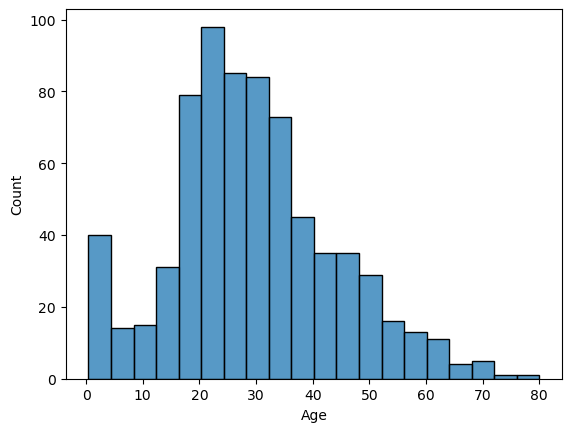

In [6]:
sns.histplot(df['Age'])

**Questions** :
   - Que représente chaque barre de l'histogramme ? Quels âges semblent les plus courants parmi les passagers ?
   - En quoi la distribution de l'âge pourrait-elle influencer une analyse business ?

2. **Visualisation de la Distribution de la variable `Fare`** :
   - Utilisez `sns.histplot()` pour afficher l’histogramme de la distribution de la variable `Fare`.

<Axes: xlabel='Fare', ylabel='Count'>

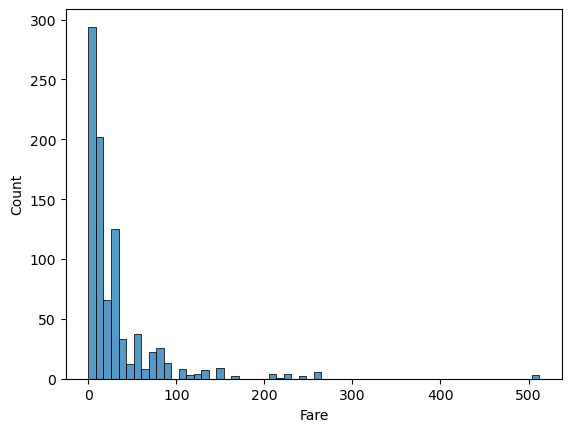

In [7]:
sns.histplot(df['Fare'])

3. **Corrélations entre Variables Numériques** :

 > **Corrélation** : La corrélation mesure la force et la direction de la relation entre deux variables. Une corrélation proche de 1 ou -1 indique une relation forte, tandis qu'une corrélation proche de 0 indique une relation faible.

   - Utilisez `.corr()` pour calculer la corrélation entre les variables numériques, puis visualisez avec `sns.heatmap()`.

<Axes: >

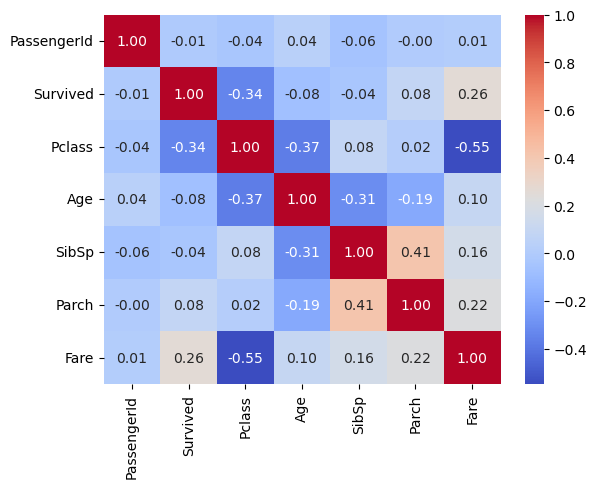

In [8]:
df_corr = df.corr(numeric_only=True)
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f")

**Questions** :
   - Quelles sont les variables fortement corrélées entre elles ? Comment interpréter ces corrélations ?
   - Pourquoi est-il important de connaître les corrélations pour éviter les redondances dans les variables ?

#### 5. **Identification des Valeurs Manquantes**

   - Utilisez `.isnull().sum()` pour identifier les colonnes avec des valeurs manquantes.

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Questions** :
   - Quelles colonnes contiennent des valeurs manquantes ? Quelle pourrait être la cause des valeurs manquantes ?
   - Comment le choix de traitement des valeurs manquantes peut-il impacter les résultats d’un modèle ?

   Les colonnes qui contiennent des valeurs manquantes sont : Age, Cabin et Embarked 

   La cause des valeurs manquantes est : 
   - Age : non renseigné à l'enregistrement, dossiers incomplets pour certains passagers (notamment 3e classe)
   - Cabin : information non collectée pour la majorité des passagers, surtout en 3e classe où les cabines n'étaient pas individuellement attribuées
   - Embarked : erreur de saisie ou oubli ponctuel (seulement 2 valeurs manquantes)


  L'impact :
  - Supprimer les lignes : on perd des données, surtout gênant pour Age (~20% des lignes)
  - Supprimer la colonne (Cabin) : on perd toute info potentiellement utile
  - Remplacer par la moyenne/médiane (Age) : simple, mais ça gomme les différences entre groupes
  - Remplacer par la valeur la plus fréquente (Embarked) : sans risque, très peu de manquants
  - Créer une catégorie "Unknown" (Cabin) : on garde l'absence de donnée comme info utile

#### 6. Gestion des Valeurs Aberrantes (Outliers)

Les valeurs aberrantes (outliers) sont des valeurs extrêmes qui peuvent influencer les résultats de certains modèles. Une méthode simple pour les identifier est l’utilisation d’un **boxplot**.

- **Boxplot pour Identifier les Valeurs Aberrantes** :
   - Utilisez `sns.boxplot()` pour visualiser la distribution de l'âge et de `fare` et identifier les valeurs aberrantes.
   


<Axes: ylabel='Age'>

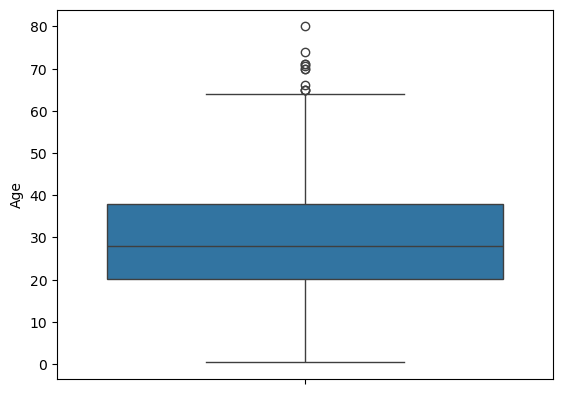

In [10]:
sns.boxplot(y=df['Age'], data=df)

<Axes: ylabel='Fare'>

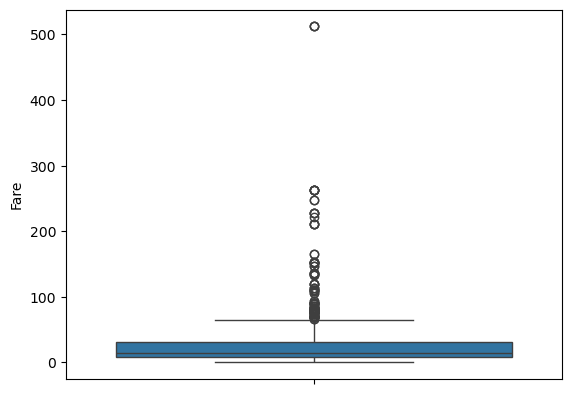

In [11]:
sns.boxplot(y='Fare', data=df)

**Questions** :
   - Que représentent les points situés en dehors des moustaches du boxplot ? 
   Ce sont les valeurs abérante.
   - Comment pourriez-vous traiter ces valeurs aberrantes (les conserver, les supprimer, les transformer) ?
   Je pourais les supprimer.

### Résumé de l'Analyse Exploratoire (EDA)

**Instructions** : Rédigez un résumé de vos observations. Notez les points suivants :
   - Les principales caractéristiques du dataset (variables, types de données, etc.).
   - Observations notables, comme les distributions de variables ou des corrélations importantes.
   - Quels aspects du dataset pourraient nécessiter des étapes de nettoyage et de transformation avant la modélisation.
   - ...

---

**1. Principales caractéristiques du dataset**
- 891 lignes, 12 colonnes.
- Variables numériques : `Age`, `Fare`, `SibSp`, `Parch` (et `Pclass`, numérique mais en réalité une catégorie ordonnée).
- Variables catégorielles : `Sex`, `Embarked`, `Pclass`.
- Variables texte peu exploitables telles quelles : `Name`, `Ticket`, `Cabin`.

**2. Observations notables**
- Age : distribution centrée entre 20 et 40 ans, avec quelques enfants/bébés.
- Fare : distribution très asymétrique , avec des tarifs élevés qui ressortent comme outliers sur le boxplot.
- Corrélations : Fare et Pclass sont liées (classe élevée = tarif plus cher), et ces deux variables sont aussi corrélées avec Survived (les passagers de 1ère classe / tarif élevé ont eu plus de chances de survivre).

**3. Aspects nécessitant nettoyage/transformation**
- Age : valeurs manquantes (~20%) → à imputer (médiane, à cause des outliers).
- Cabin : très grande proportion de valeurs manquantes (>75%) → à supprimer ou transformer en indicateur binaire.
- Embarked : quelques valeurs manquantes → à imputer par le mode.
- Sex et Embarked : à encoder (one-hot/label encoding) pour la modélisation.
- Fare et Age : outliers à traiter ou transformer (ex. transformation log pour Fare).

## **4. Prétraitement des Données**

### Définition

Le **prétraitement des données** consiste à préparer les données pour l’entraînement du modèle. Il inclut le nettoyage des données, le traitement des valeurs manquantes, l’encodage des variables catégorielles, la gestion des valeurs aberrantes, et la normalisation.

### Objectifs du Prétraitement des Données

- **Assurer la qualité des données** : Traiter les valeurs manquantes et aberrantes pour éviter des biais dans les modèles.
- **Préparer les données pour les algorithmes** : Rendre les données exploitables pour le modèle choisi, en appliquant des transformations adaptées.

### Étapes du Prétraitement

---

### 1. Gestion des Valeurs Manquantes

La gestion des valeurs manquantes est essentielle pour garantir la qualité des données avant toute analyse ou modélisation. Les valeurs manquantes peuvent être traitées de différentes manières en fonction du type de variable et de la distribution des données. Voici les stratégies d’imputation couramment utilisées :

- **Moyenne** : Pour les variables continues avec une distribution symétrique et sans valeurs extrêmes.
- **Médiane** : Pour les variables continues susceptibles de contenir des valeurs extrêmes, car elle est moins sensible aux valeurs aberrantes.
- **Mode** : Pour les variables catégorielles, en remplaçant les valeurs manquantes par la catégorie la plus fréquente.
- **Suppression** : Pour les colonnes ayant plus de 70 % de valeurs manquantes, car elles contiennent peu d’informations exploitables.
- **Méthodes avancées** : Dans certains cas, des modèles de Machine Learning peuvent prédire les valeurs manquantes, mais cela nécessite des ressources supplémentaires et une analyse approfondie.

#### **Exemple d’Imputation pour la Colonne `Age`**

Pour la colonne `Age`, nous utilisons la **médiane** pour remplacer les valeurs manquantes, car cette variable continue contient des valeurs extrêmes. Utilisez `.fillna()` pour remplacer les valeurs manquantes


In [12]:
df.fillna(df['Age'].mean())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,29.699118,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,29.699118,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,29.699118,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,29.699118,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,29.699118,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


**Question** : 
- Pourquoi utiliser la médiane peut-il être plus avantageux que la moyenne pour remplacer les valeurs manquantes ?

La médiane est plus avantageuse que la moyenne car elle est **moins sensible aux valeurs extrêmes (outliers)**.

- La **moyenne** prend en compte toutes les valeurs, y compris les extrêmes. Si quelques passagers ont un âge très élevé (ex. 80 ans), ça tire la moyenne vers le haut, même si la majorité des passagers sont plus jeunes.
- La **médiane** est la valeur du milieu une fois les données triées — elle n'est pas affectée par l'ampleur des valeurs extrêmes, seulement par leur position.

Concrètement pour `Age` : la distribution contient quelques passagers âgés qui déforment la moyenne. Utiliser la médiane donne une valeur de remplacement plus représentative de l'âge "typique" d'un passager, et évite d'introduire un biais dans le modèle.


#### **Application des Stratégies pour les Autres Variables**

Pour les autres variables, choisissez la stratégie d’imputation appropriée selon la nature de la colonne :

- Utilisez la **moyenne** ou la **médiane** pour les variables continues, selon la présence de valeurs extrêmes.
- Utilisez le **mode** pour les variables catégorielles.
- Supprimez les colonnes avec un grand nombre de valeurs manquantes si elles contiennent plus de 70 % de données manquantes.

**Questions** :
- Quels sont les avantages et inconvénients d'utiliser la moyenne, la médiane ou le mode pour gérer les valeurs manquantes ?

**Moyenne**
- Avantage : simple à calculer, conserve la somme totale des valeurs, adaptée aux variables continues à distribution symétrique.
- Inconvénient : très sensible aux valeurs extrêmes (outliers), ce qui peut fausser le remplacement si la distribution est asymétrique.

**Médiane**
- Avantage : robuste aux valeurs extrêmes, plus représentative en cas de distribution asymétrique (skewed).
- Inconvénient : ignore une partie de l'information de la distribution (ne prend pas en compte l'ampleur des écarts, seulement l'ordre).

**Mode**
- Avantage : seule option adaptée aux variables catégorielles, remplace par la catégorie la plus fréquente donc reste cohérent avec les données existantes.
- Inconvénient : peut renforcer un déséquilibre déjà présent (sur-représenter une catégorie déjà majoritaire), et n'a pas de sens pour des variables numériques continues.

**En résumé** : le choix dépend du type de variable (numérique vs catégorielle) et de la présence ou non de valeurs extrêmes.


---
### 2. **Calcule et Traitement des Valeurs Aberrantes avec la methode de l'IQR**

Une fois que nous avons identifié des valeurs aberrantes lors de l'exploration des données, nous pouvons maintenant les traiter dans la phase de prétraitement. Les valeurs aberrantes sont des observations extrêmes qui se situent en dehors de la majorité des données et peuvent affecter la performance de certains modèles de Machine Learning.

#### **Méthode de l'IQR pour le Traitement des Valeurs Aberrantes**

Pour repérer les valeurs aberrantes de manière quantitative, nous utilisons l'Intervalle Interquartile (`IQR`). En rappel, l'IQR est défini comme la différence entre le troisième quartile (`Q3`) et le premier quartile (`Q1`) : $IQR = Q3 - Q1$

Pour identifier les valeurs aberrantes, on utilise les bornes suivantes :
- **Borne inférieure** : $ Q1 - 1.5 \times IQR $
- **Borne supérieure** : $ Q3 + 1.5 \times IQR $

Les valeurs en dehors de cet intervalle sont considérées comme aberrantes.

##### **Étapes pour Traiter les Valeurs Aberrantes**

1. **Calcul des Quartiles et de l'IQR** :
   - Calculez les quartiles  `Q1` et `Q3`  pour les variables `Age` et `Fare`.
   - Déterminez l'IQR en soustrayant `Q1` de `Q3`.

2. **Détection des Valeurs Aberrantes** :
   - Calculez les bornes inférieure et supérieure pour chaque variable.
   - Filtrez les valeurs de `Age` et `Fare` qui se trouvent en dehors de ces bornes.

3. **Options pour le Traitement** :
   - **Suppression** : Supprimer les valeurs aberrantes si elles sont peu nombreuses et qu'elles risquent d'affecter le modèle.
   - **Transformation** : Appliquer une transformation (comme la transformation logarithmique) pour réduire l’impact des valeurs extrêmes.
   - **Imputation** : Remplacer les valeurs aberrantes par la médiane ou un autre résumé statistique si elles sont essentielles pour l’analyse.

**Instructions** :
- Calculez les valeurs de `Q1`, `Q3` et `IQR` pour `Age` et `Fare`.
- Déterminez les bornes pour filtrer les valeurs aberrantes et décidez comment les traiter en fonction du contexte.

In [13]:
# Calcul quartiles
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]
print(f"Nombre d'outliers : {len(outliers)}")
print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")


Nombre d'outliers : 11
Q1: 20.125
Q3: 38.0
IQR: 17.875


**Questions** :
- Quels sont les avantages de transformer ou de supprimer les valeurs aberrantes dans `Age` et `Fare` ?
- Comment ces décisions pourraient-elles influencer les résultats de votre modèle de Machine Learning ?

---

 Avantages de transformer/supprimer les outliers
Supprimer, ça simplifie tout mais on perd des infos. Transformer (log, plafonnement), on garde l'info tout en atténuant l'effet extrême — souvent plus malin, surtout pour Fare qui a une distribution très étalée.

Impact sur le modèle
Si on supprime, on risque de virer des cas réels et utiles (genre les passagers 1ère classe avec un Fare élevé, qui ont plus survécu). Les modèles genre régression ou KNN sont sensibles à ces valeurs extrêmes, alors que les arbres de décision (Random Forest...) s'en fichent pas mal.

### 3. **Encodage des Variables Catégorielles**

1. **Encodage One-Hot** :
   - Utilisez `pd.get_dummies()` pour encoder les variables catégorielles (`Sex`, `Embarked`) en variables numériques.

In [14]:
# Insérez votre code ici pour encoder les variables catégorielles
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'])
df_encoded.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,False,True,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,True,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,True,False,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,True,False,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,False,True,False,False,True


**Question** : Comment l’encodage des variables catégorielles peut-il aider certains algorithmes de Machine Learning à mieux traiter les données ?

L'encodage des variable catégoriellespermet de placer ces deux variables sur une échelle de true à false, ce qui facilite les calculs et rend les valeurs comparables.

---

### 4. Normalisation et Standardisation des Variables

La **normalisation** et la **standardisation** sont des étapes importantes dans le prétraitement des données pour s’assurer que toutes les variables sont sur une même échelle. Cela évite que certaines variables, qui ont des valeurs plus grandes ou plus petites, influencent davantage le modèle que d'autres, simplement à cause de leur amplitude.

- **Normalisation** : La normalisation consiste à rescaler les données pour qu’elles soient comprises entre 0 et 1. Cela est utile lorsque les données contiennent des valeurs de tailles très différentes. Par exemple, si l’une des variables représente des montants financiers en milliers et qu'une autre représente des pourcentages, la normalisation permet de placer ces deux variables sur une échelle de 0 à 1, ce qui facilite les calculs et rend les valeurs comparables.

  Formule de la normalisation : $ x_{\text{norm}} = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}$

- **Standardisation** : La standardisation consiste à transformer les données pour qu’elles aient une moyenne de 0 et un écart-type de 1. Cette méthode est utile lorsque les valeurs sont distribuées autour d’une moyenne mais avec des écarts variés. La standardisation centre les données autour de 0, ce qui aide à équilibrer leur influence dans les calculs du modèle.

  Formule de la standardisation :
  $ z = \frac{x - \mu}{\sigma}$, où $ \mu $ est la moyenne de la variable et $ \sigma $ est son écart-type.

**Pourquoi normaliser ou standardiser ?**  
Ces transformations sont appliquées pour que les variables aient une échelle comparable, ce qui permet d’éviter que certaines variables dominent les calculs simplement en raison de leur amplitude. Cela peut aussi améliorer la performance des modèles de Machine Learning qui sont sensibles aux différences d’échelle entre les variables, comme les modèles de distances.

##### **Instructions pour Appliquer la Normalisation et la Standardisation**

- **Normalisation** : Utilisez `MinMaxScaler` de `sklearn.preprocessing` pour transformer les variables numériques afin qu’elles soient comprises entre 0 et 1.

In [15]:
# Insérez votre code ici pour normalisation les variables numériques
from sklearn.preprocessing import MinMaxScaler

df_scaled = df.copy()
scaler = MinMaxScaler()
df_scaled[['Age', 'Fare']] = scaler.fit_transform(df_scaled[['Age', 'Fare']])
df_scaled[['Age', 'Fare']].head()

,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


**Question** : Question : Pourquoi la normalisation pourrait-elle être utile pour certains types d’analyses ?

La normalisation évite qu'une variable (comme le prix, qui va jusqu'à 500) écrase une autre (comme l'âge, qui va jusqu'à 80) juste à cause de sa taille. Toutes les variables sont ramenées entre 0 et 1, donc chacune compte à sa juste valeur dans l'analyse.

- **Standardisation** : Utilisez `StandardScaler` de `sklearn.preprocessing` pour transformer les variables numériques afin qu’elles aient une moyenne de 0 et un écart-type de 1.

In [16]:
# Insérez votre code ici pour standardiser les variables numériques
from sklearn.preprocessing import StandardScaler

df_standard = df.copy()
scaler = StandardScaler()
df_standard[['Age', 'Fare']] = scaler.fit_transform(df_standard[['Age', 'Fare']])
df_standard[['Age', 'Fare']].head()

,Age,Fare
0,-0.530377,-0.502445
1,0.571831,0.786845
2,-0.254825,-0.488854
3,0.365167,0.420730
4,0.365167,-0.486337


**Question** : Dans quel cas pensez-vous que la standardisation des données pourrait être importante ?

La standardisation est importante quand un modèle compare des distances entre les données (comme KNN) ou apprend petit à petit en ajustant ses calculs (comme la régression) : sans elle, une variable avec de grandes valeurs comme Fare écraserait une variable comme Age juste à cause de sa taille, même si elle n'est pas plus importante.

---
### Feature Engineering

Créer de nouvelles variables à partir des données existantes peut améliorer les performances du modèle. Par exemple :
   - **Membre de Famille** : Combinez `SibSp` (nombre de frères/sœurs/époux) et `Parch` (nombre de parents/enfants) pour créer une nouvelle variable représentant le nombre total de membres de la famille.

In [17]:
# Insérez votre code ici pour créer la variable Membre de Famille

df['Membre_de_Famille'] = df['SibSp'] + df['Parch']
df[['SibSp', 'Parch', 'Membre_de_Famille']].head()

,SibSp,Parch,Membre_de_Famille
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


**Question** : Comment l’ajout de cette nouvelle variable pourrait-il aider un modèle de Machine Learning à mieux prédire la survie ?

Le modèle peut plus facilement repérer ce genre de tendance.

### Autres Étapes de Prétraitement

D'autres transformations peuvent être nécessaires selon les besoins :
   - **Transformation de l'âge en groupes d'âge** : Regroupez la colonne `Age` en catégories comme "Enfant", "Adolescent", "Adulte", "Senior".
   - **Transformation logarithmique** : Réduisez l'impact des valeurs extrêmes en appliquant une transformation logarithmique. Par exemple, appliquez `np.log1p()` sur la colonne `Fare`.

In [18]:
# Insérez votre code ici pour les transformations supplémentaires et la visualisation avant/après

# Regrouper l'âge en catégories
bins = [0, 12, 18, 60, 100]
labels = ['Enfant', 'Adolescent', 'Adulte', 'Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Transformation logarithmique de Fare pour réduire l'impact des valeurs extrêmes
df['Fare_log'] = np.log1p(df['Fare'])

print(df['Fare_log'])

0      2.110213
1      4.280593
2      2.188856
3      3.990834
4      2.202765
         ...   
886    2.639057
887    3.433987
888    3.196630
889    3.433987
890    2.169054
Name: Fare_log, Length: 891, dtype: float64


**Conversions des Transformations** :
   - **Binning (ou catégorisation)** : Transformer des variables continues comme l'âge en groupes d'âge.
   - **Log transformation** : Appliquée sur des valeurs numériques étendues pour en réduire la dispersion.

**Question** : Comment ces transformations peuvent-elles affecter la distribution des données ? Dans quel cas sont-elles nécessaires ?

---

## **Résumé et Conclusion**

Dans ce module, vous avez appris :
- Découvert les applications du Machine Learning en entreprise.
- L'importance de l'exploration des données et les outils pour l'EDA.
- Les techniques de prétraitement des données : gestion des valeurs manquantes, encodage, normalisation, valeurs aberrantes, et **feature engineering**.

Ces compétences sont cruciales pour préparer des données prêtes pour la modélisation en Machine Learning.